# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Database Connection

In [2]:
SERVER = "localhost"
DATABASE = "olistDW"

connection_string = (
    f"mssql+pyodbc://@{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("Connected Successfully")

Connected Successfully


# Test Connection

In [3]:
query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE';
"""

df_table_name = pd.read_sql(query, engine)

df_table_name

,TABLE_NAME
0,Dim_Customer
1,Dim_Product
2,Dim_Seller
3,Dim_Date
4,Fact_Sales


In [4]:
table_names = df_table_name['TABLE_NAME'].tolist()

for table_name in table_names:

    query = f"""
    SELECT TOP 5 *
    FROM {table_name}
    """

    df_test = pd.read_sql(query, engine)

    print(f"\nTable: {table_name}")
    display(df_test)


Table: Dim_Customer


,customer_id,city,state,customer_sk
0,00012a2ce6f8dcda20d059ce98491703,osasco,SP,1
1,000161a058600d5901f007fab4c27140,itapecerica,MG,2
2,0001fd6190edaaf884bcaf3d49edf079,nova venecia,ES,3
3,0002414f95344307404f0ace7a26f1d5,mendonca,MG,4
4,000379cdec625522490c315e70c7a9fb,sao paulo,SP,5



Table: Dim_Product


,product_id,category,weight,product_sk
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,300.00,1
1,00088930e925c41fd95ebfe695fd2655,automotivo,1225.00,2
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,300.00,3
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,550.00,4
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,250.00,5



Table: Dim_Seller


,seller_id,city,state,seller_sk
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP,1
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,2
2,001e6ad469a905060d959994f1b41e4f,sao goncalo,RJ,3
3,002100f778ceb8431b7a1020ff7ab48f,franca,SP,4
4,003554e2dce176b5555353e4f3555ac8,goiania,GO,5



Table: Dim_Date


,date,year,month,quarter,week,day,month_name,day_name
0,2016-09-04,2016,9,3,37,4,September,Sunday
1,2016-09-05,2016,9,3,37,5,September,Monday
2,2016-09-13,2016,9,3,38,13,September,Tuesday
3,2016-09-15,2016,9,3,38,15,September,Thursday
4,2016-10-02,2016,10,4,41,2,October,Sunday



Table: Fact_Sales


,sales_key,order_id,customer_id,product_id,seller_id,order_date,payment_value,freight_value,quantity
0,1,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-19,157.60,11.65,1
1,2,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-02,65.39,11.40,1
2,3,000f25f4d72195062c040b12dce9a18a,86ade8ebc14f18dd6c3ea75bd0eb7534,1c05e0964302b6cf68ca0d15f326c6ba,7c67e1448b00f6e969d365cea6b010ab,2018-03-07,164.39,44.40,1
3,4,0010b2e5201cc5f1ae7e9c6cc8f5bd00,57ef317d4818cb42680fc9dfd13867ce,5a419dbf24a8c9718fe522b81c69f61a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-09-11,65.50,16.60,1
4,5,00119ff934e539cf26f92b9ef0cdfed8,7dd2e283f47deac853cf70f3b63c8d86,21b1c2f67a9aafb5af0eb06c13b9dbda,c864036feaab8c1659f65ea4faebe1da,2017-08-06,236.88,16.98,1


In [5]:
fact_sales = pd.read_sql(
    "SELECT * FROM Fact_Sales",
    engine
)

dim_customer = pd.read_sql(
    "SELECT * FROM Dim_Customer",
    engine
)

dim_product = pd.read_sql(
    "SELECT * FROM Dim_Product",
    engine
)

dim_seller = pd.read_sql(
    "SELECT * FROM Dim_Seller",
    engine
)

dim_date = pd.read_sql(
    "SELECT * FROM Dim_Date",
    engine
)

In [6]:
for name, df in {
    'Fact_Sales': fact_sales,
    'Dim_Customer': dim_customer,
    'Dim_Product': dim_product,
    'Dim_Seller': dim_seller,
    'Dim_Date': dim_date
}.items():

    print(f"\n{name}")
    print(df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())


Fact_Sales
(230248, 9)

Missing Values:
sales_key        0
order_id         0
customer_id      0
product_id       0
seller_id        0
order_date       0
payment_value    0
freight_value    0
quantity         0
dtype: int64

Duplicates:
0

Dim_Customer
(99441, 4)

Missing Values:
customer_id    0
city           0
state          0
customer_sk    0
dtype: int64

Duplicates:
0

Dim_Product
(32951, 4)

Missing Values:
product_id      0
category      610
weight          2
product_sk      0
dtype: int64

Duplicates:
0

Dim_Seller
(3095, 4)

Missing Values:
seller_id    0
city         0
state        0
seller_sk    0
dtype: int64

Duplicates:
0

Dim_Date
(634, 8)

Missing Values:
date          0
year          0
month         0
quarter       0
week          0
day           0
month_name    0
day_name      0
dtype: int64

Duplicates:
0


In [7]:
sales = (
    fact_sales
    .merge(dim_customer,
           on='customer_id',
           how='left')

    .merge(dim_product,
           on='product_id',
           how='left')

    .merge(dim_seller,
           on='seller_id',
           how='left',
           suffixes=('_customer','_seller'))

    .merge(dim_date,
           left_on='order_date',
           right_on='date',
           how='left')
)

In [8]:
sales['payment_value'].sum()

np.float64(40616269.42)

In [9]:
sales['order_id'].nunique()

98665

In [10]:
sales['customer_id'].nunique()

98665

In [11]:
sales['payment_value'].mean()

np.float64(176.40226807616136)

In [12]:
monthly_sales = (
    sales
    .groupby(['year','month'])
    ['payment_value']
    .sum()
    .reset_index()
)

<Axes: title={'center': 'Monthly Sales'}, xlabel='month'>

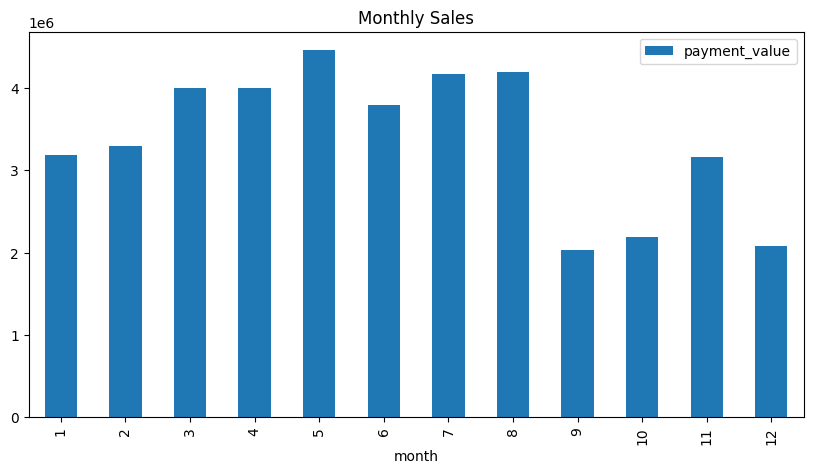

In [13]:
monthly_sales = (
    sales
    .groupby('month', as_index=False)['payment_value']
    .sum()
    .sort_values('month')
)

monthly_sales.plot(
    x='month',
    y='payment_value',
    kind='bar',
    figsize=(10, 5),
    title='Monthly Sales'
)

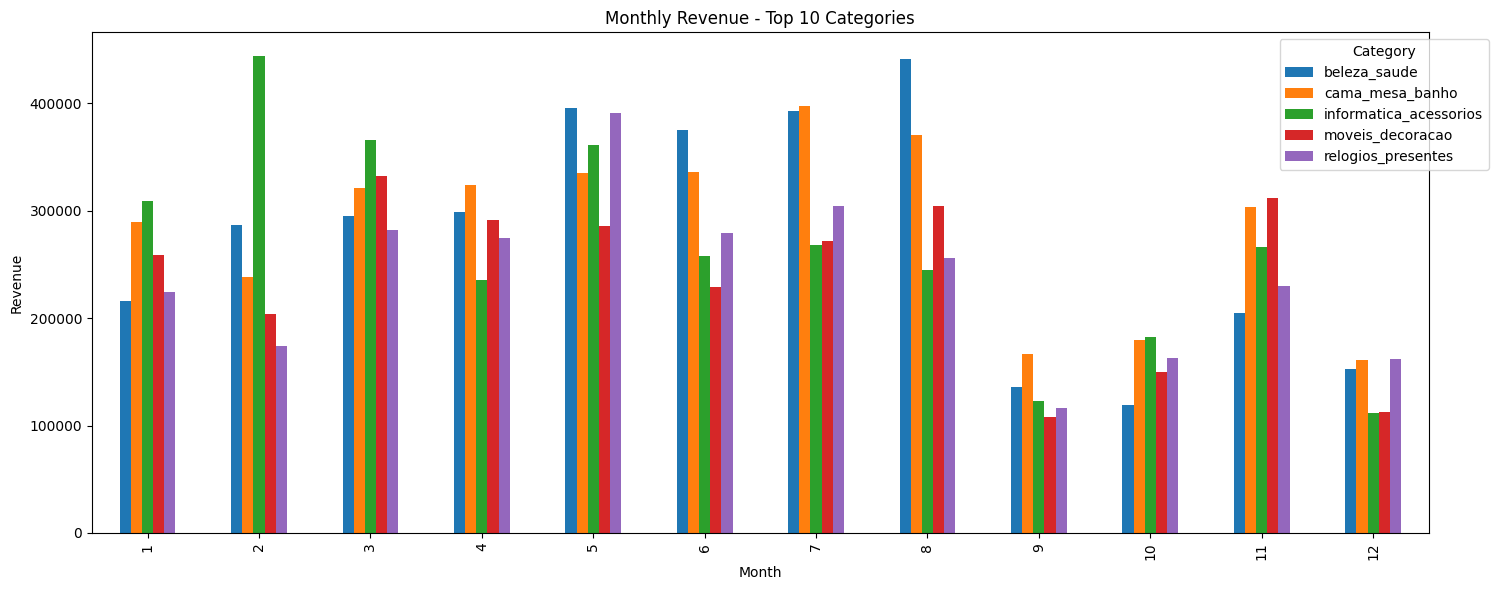

In [14]:
top_categories = (
    sales.groupby('category')['payment_value']
    .sum()
    .nlargest(5)
    .index
)

filtered_sales = sales[sales['category'].isin(top_categories)]

monthly_category_sales = (
    filtered_sales
    .groupby(['month', 'category'])['payment_value']
    .sum()
    .reset_index()
)

pivot_sales = monthly_category_sales.pivot(
    index='month',
    columns='category',
    values='payment_value'
).fillna(0)

pivot_sales.plot(
    kind='bar',
    figsize=(15, 6)
)

plt.title('Monthly Revenue - Top 10 Categories')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

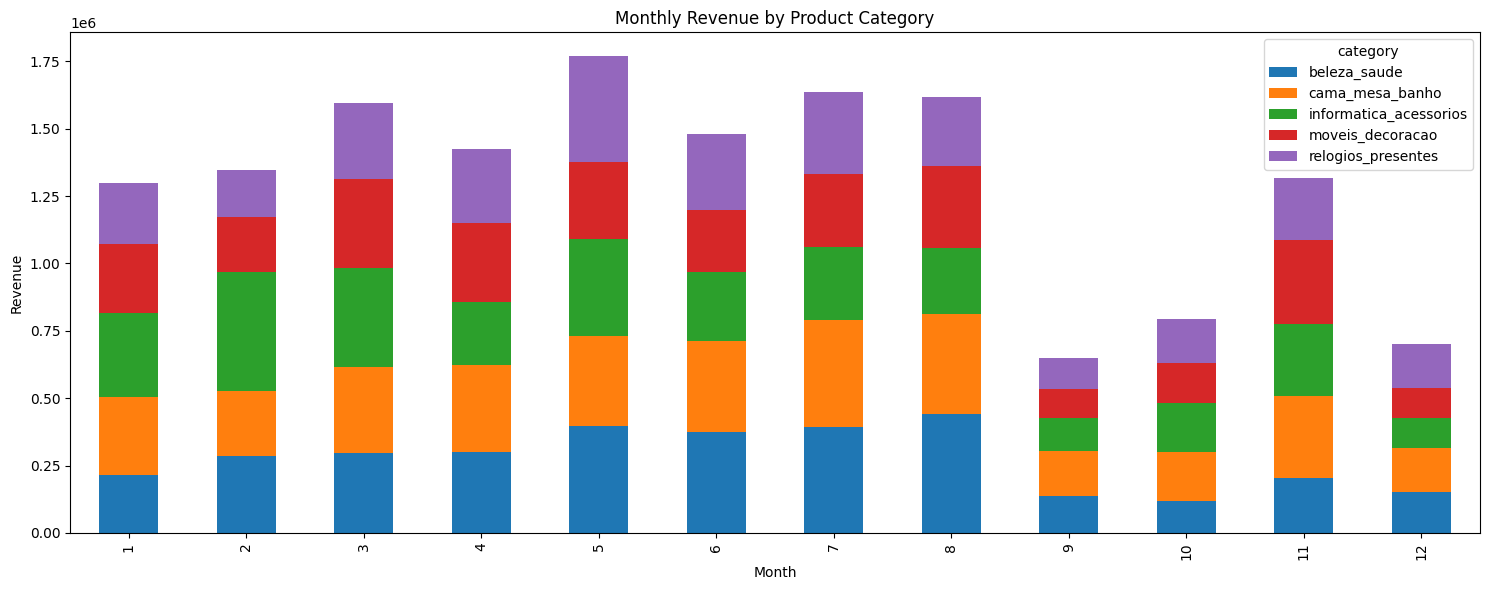

In [15]:
pivot_sales.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 6)
)

plt.title('Monthly Revenue by Product Category')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [16]:
sales.groupby(
    'day_name'
)['payment_value'].sum()

day_name
Friday      6022319.70
Monday      6628751.24
Saturday    4292803.74
Sunday      4543097.64
Thursday    6190528.64
Tuesday     6624646.40
Wednesday   6314122.06
Name: payment_value, dtype: float64

# Sale days of the week

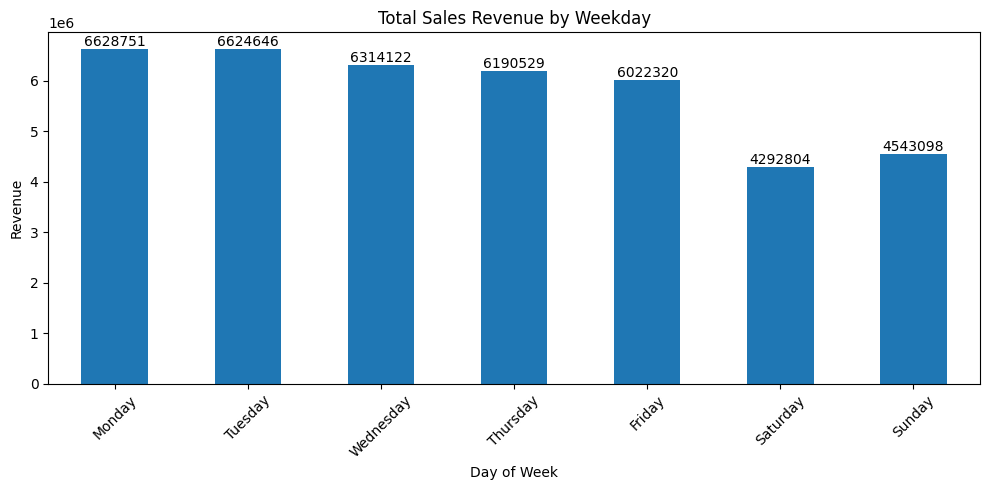

In [17]:


day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_sales = (
    sales.groupby('day_name')['payment_value']
    .sum()
    .reindex(day_order)
)

ax = day_sales.plot(
    kind='bar',
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Total Sales Revenue by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Number of orders per day of the week


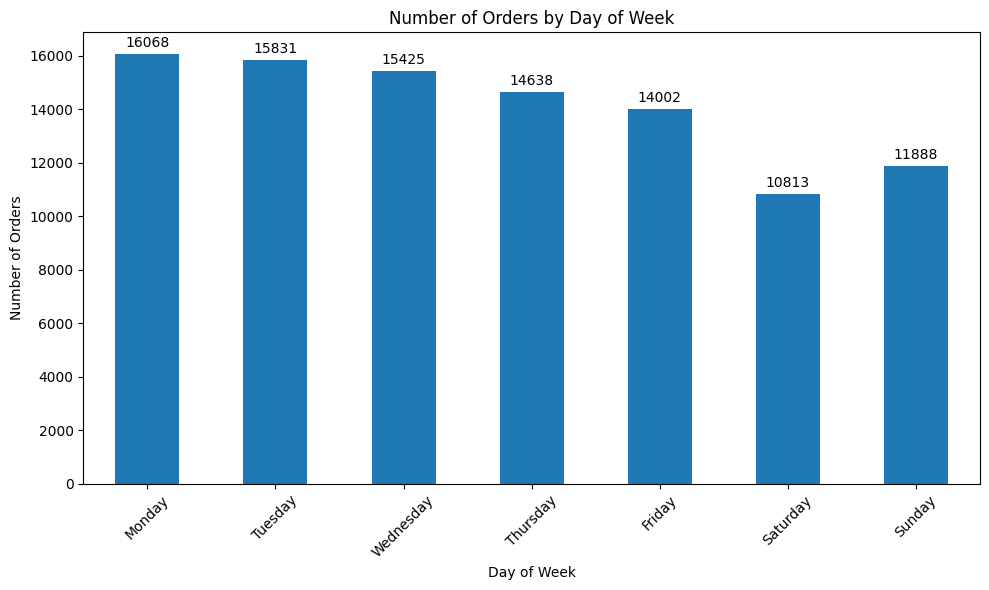

In [18]:
import matplotlib.pyplot as plt

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_orders = (
    sales.groupby('day_name')['order_id']
    .nunique()
    .reindex(day_order)
)

ax = day_orders.plot(
    kind='bar',
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

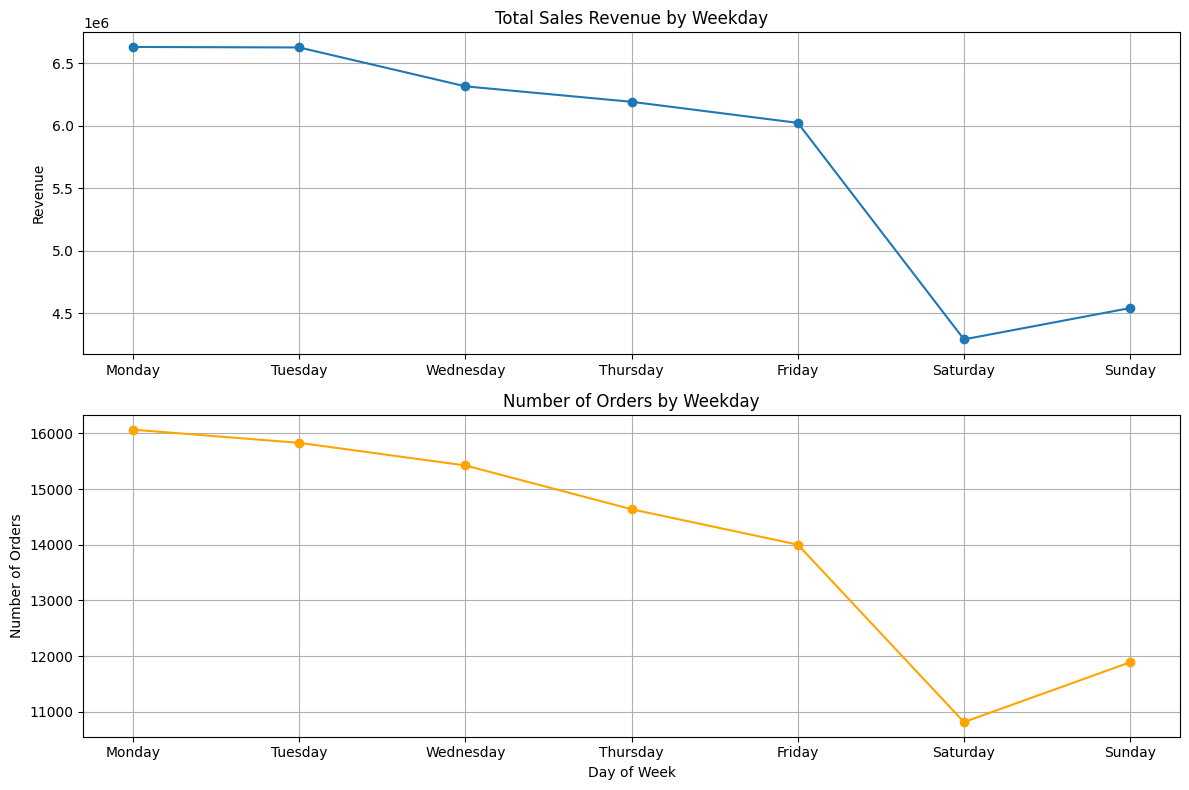

In [19]:

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# --------------------
# Revenue per day
# --------------------
day_sales = (
    sales.groupby('day_name')['payment_value']
    .sum()
    .reindex(day_order)
)

# --------------------
# Orders per day
# --------------------
day_orders = (
    sales.groupby('day_name')['order_id']
    .nunique()
    .reindex(day_order)
)

# --------------------
# Plot: Two line charts in one figure
# --------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Revenue line chart
axes[0].plot(day_order, day_sales.values, marker='o')
axes[0].set_title('Total Sales Revenue by Weekday')
axes[0].set_ylabel('Revenue')
axes[0].grid(True)

# Orders line chart
axes[1].plot(day_order, day_orders.values, marker='o', color='orange')
axes[1].set_title('Number of Orders by Weekday')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('Day of Week')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Weekly Sales and Order Pattern Analysis

The analysis of weekly performance shows a clear downward trend across both total sales revenue and the number of orders.

Both metrics peak on **Monday**, indicating the strongest business activity at the beginning of the week. From Monday onward, there is a consistent decline throughout the weekdays. This downward trend continues gradually until **Saturday**, which records the lowest level of both revenue and order volume.

This pattern suggests that customer purchasing activity is significantly higher at the start of the week and progressively weakens towards the weekend. The consistency between revenue and order count trends also indicates that the variation in sales is primarily driven by the number of transactions rather than changes in average order value.

In [20]:
weekend_categories = (
    sales[sales['day_name'].isin(['Saturday', 'Sunday'])]
    ['category']
    .value_counts()
)

print(weekend_categories)

category
cama_mesa_banho                                   5580
beleza_saude                                      4406
moveis_decoracao                                  4038
esporte_lazer                                     3852
utilidades_domesticas                             3349
informatica_acessorios                            3052
relogios_presentes                                2865
telefonia                                         2137
ferramentas_jardim                                1981
brinquedos                                        1908
automotivo                                        1877
cool_stuff                                        1857
perfumaria                                        1543
bebes                                             1434
eletronicos                                       1304
papelaria                                         1078
pet_shop                                          1008
fashion_bolsas_e_acessorios                        988
m

In [21]:
weekend_sales = (
    sales[sales['day_name'].isin(['Saturday', 'Sunday'])]
    .groupby('category')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

print(weekend_sales)

category
cama_mesa_banho                                  853960.06
beleza_saude                                     767876.74
relogios_presentes                               702704.86
moveis_decoracao                                 630585.16
esporte_lazer                                    604402.48
utilidades_domesticas                            472764.74
informatica_acessorios                           455031.90
automotivo                                       372357.34
cool_stuff                                       359368.66
ferramentas_jardim                               342493.26
brinquedos                                       277434.72
bebes                                            228752.64
moveis_escritorio                                224869.02
perfumaria                                       221648.36
telefonia                                        213968.74
pet_shop                                         167368.26
papelaria                                      

# Categories that perform better on the weekend (Saturday + Sunday)
# This chart shows management which categories are suitable for the weekend campaign

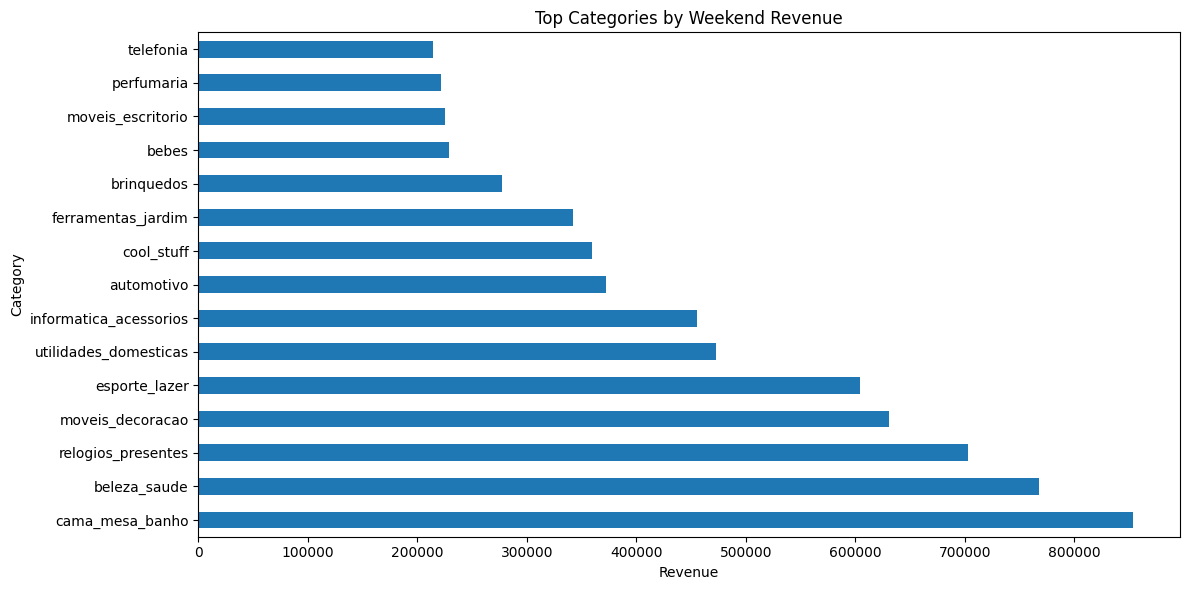

In [22]:
weekend_category_sales = (
    sales[sales['day_name'].isin(['Saturday', 'Sunday'])]
    .groupby('category')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

weekend_category_sales.plot(
    kind='barh',
    figsize=(12,6)
)

plt.title('Top Categories by Weekend Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

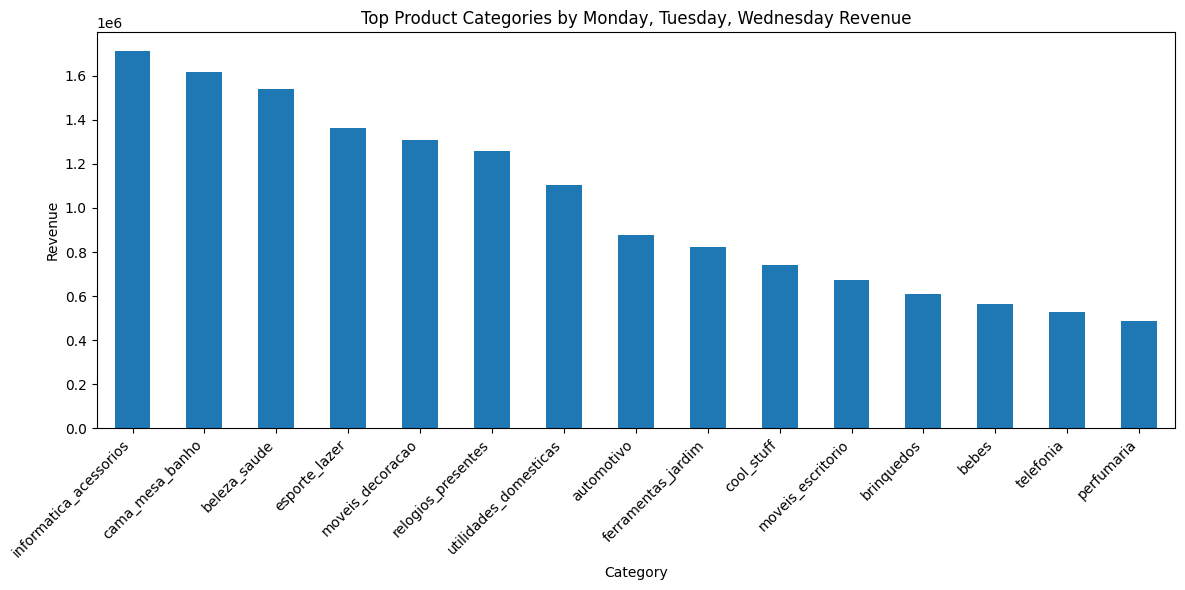

In [23]:

weekend_sales = (
    sales[sales['day_name'].isin(['Monday', 'Tuesday', 'Wednesday'])]
    .groupby('category')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

weekend_sales.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top Product Categories by Monday, Tuesday, Wednesday Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find the best-selling products of the weekend

In [24]:
weekend_products = (
    sales[sales['day_name'].isin(['Saturday', 'Sunday'])]
    .groupby(['product_id','category'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('payment_value', ascending=False)
)

weekend_products.head(20)

,product_id,category,payment_value
1257,19936fa4f614ee0590d3b77ac83fd648,telefonia_fixa,71632.00
9010,bb50f2e236e5eea0100680137654686c,beleza_saude,42758.84
10158,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,34043.04
5296,6dde44b4172999f35f08654d06bad633,moveis_escritorio,33138.58
7362,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,30753.30
4085,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,29992.66
8282,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,27021.30
10378,d6160fb7873f184099d9bc95e30376af,pcs,26865.96
2660,368c6c730842d78016ad823897a372db,ferramentas_jardim,26141.76
11978,f819f0c84a64f02d3a5606ca95edd272,relogios_presentes,25998.56


# Finding the right products for your Bundle Campaign
# Target : A product that sells well on Monday and Tuesday + a low-selling product in the same category

# Best-selling products on Monday and Tuesday

In [25]:
top_weekday_products = (
    sales[sales['day_name'].isin(['Monday','Tuesday'])]
    .groupby(['product_id','category'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('payment_value', ascending=False)
)

top_weekday_products

,product_id,category,payment_value
12925,d5991653e037ccb7af6ed7d94246b249,informatica_acessorios,84599.70
11294,bb50f2e236e5eea0100680137654686c,beleza_saude,59298.74
12681,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,48696.08
13981,e7cc48a9daff5436f63d3aad9426f28b,telefonia,40412.04
6621,6cdd53843498f92890544667809f1595,beleza_saude,39777.02
...,...,...,...
9481,9cf02957cdf023b6b8dfebede6c64755,utilidades_domesticas,29.30
7689,7de123c822c488ccab0151f37a521b5b,utilidades_domesticas,28.76
9423,9beabf555d105ca84a74570e39e64852,automotivo,28.58
3615,3c3e5e9de1f81dc29a6a8bc3e0fff6c0,fashion_bolsas_e_acessorios,27.56


# Low-selling products in the same category

In [26]:
low_selling_products = (
    sales.groupby(['product_id','category'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('payment_value')
)


low_selling_products

,product_id,category,payment_value
9064,46fce52cef5caa7cc225a5531c946c8b,beleza_saude,19.18
6269,310dc32058903b6416c71faff132df9e,papelaria,20.14
1918,0eeeb45e2f5911fd44282e5bb0c624ff,musica,23.12
13218,680cc8535be7cc69544238c1d6a83fe8,pet_shop,23.24
10581,5304ff3fa35856a156e1170a6022d34d,artes,24.44
...,...,...,...
13813,6cdd53843498f92890544667809f1595,beleza_saude,129651.34
26545,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,141115.80
8456,422879e10f46682990de24d770e7f83d,ferramentas_jardim,159024.44
23650,bb50f2e236e5eea0100680137654686c,beleza_saude,163774.84


In [27]:
top_products = (
    top_weekday_products
    .groupby('category')
    .head(3)
)

low_products = (
    low_selling_products
    .groupby('category')
    .head(3)
)

bundle_candidates = (
    top_products[['product_id','category']]
    .merge(
        low_products[['product_id','category']],
        on='category',
        suffixes=('_top','_low')
    )
)

bundle_candidates.head(20)

,product_id_top,category,product_id_low
0,d5991653e037ccb7af6ed7d94246b249,informatica_acessorios,972f43585f3080ef953aed0609cb416c
1,d5991653e037ccb7af6ed7d94246b249,informatica_acessorios,eee2fb3dceb9ffd8a99dd4bc4b7e860a
2,d5991653e037ccb7af6ed7d94246b249,informatica_acessorios,1561c00eeaa35a78b884771143c513f5
3,bb50f2e236e5eea0100680137654686c,beleza_saude,46fce52cef5caa7cc225a5531c946c8b
4,bb50f2e236e5eea0100680137654686c,beleza_saude,da86f3242cb55a55dd9cd7b19d951685
5,bb50f2e236e5eea0100680137654686c,beleza_saude,e987fc6af8290fcf1db0510d52b65795
6,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,972f43585f3080ef953aed0609cb416c
7,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,eee2fb3dceb9ffd8a99dd4bc4b7e860a
8,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,1561c00eeaa35a78b884771143c513f5
9,e7cc48a9daff5436f63d3aad9426f28b,telefonia,c033f1d184d2a7206c602c1bbfa670ee


# Business Recommendations

# Launch weekend promotions for categories with historically strong Saturday/Sunday demand.
# Bundle low-performing products with top-selling products from the same category.
# Schedule marketing campaigns on Friday to drive weekend conversions.
# Prioritize inventory planning for products with consistently high Monday and Tuesday demand.

# product analysis

In [28]:
sales.groupby(
    'category'
)['payment_value'].sum() \
.sort_values(ascending=False)

category
cama_mesa_banho                                  3425107.34
beleza_saude                                     3314746.24
informatica_acessorios                           3170660.90
moveis_decoracao                                 2860352.78
relogios_presentes                               2858433.36
esporte_lazer                                    2784255.12
utilidades_domesticas                            2189516.26
automotivo                                       1704588.66
ferramentas_jardim                               1676561.50
cool_stuff                                       1559396.00
moveis_escritorio                                1293652.98
brinquedos                                       1238075.38
bebes                                            1079691.32
perfumaria                                       1013477.32
telefonia                                         973764.10
papelaria                                         634880.14
pet_shop                       

In [29]:
sales.groupby(
    'category'
)['quantity'].sum() \
.sort_values(ascending=False)

category
cama_mesa_banho                                   28204
moveis_decoracao                                  23595
beleza_saude                                      22501
esporte_lazer                                     20211
informatica_acessorios                            20060
utilidades_domesticas                             18581
relogios_presentes                                13405
ferramentas_jardim                                12003
telefonia                                         10510
automotivo                                         9923
brinquedos                                         9056
cool_stuff                                         8360
perfumaria                                         7718
bebes                                              6995
eletronicos                                        6272
papelaria                                          5720
moveis_escritorio                                  5190
fashion_bolsas_e_acessorios            

# List of best-selling products

In [30]:
top_products = (
    sales.groupby(['product_id'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('payment_value', ascending=False)
)

top_products.head(20)

,product_id,payment_value
11352,5769ef0a239114ac3a854af00df129e4,218625.28
24086,bb50f2e236e5eea0100680137654686c,163774.84
8613,422879e10f46682990de24d770e7f83d,159024.44
27039,d1c427060a0f73f6b889a5c7c61f2ac4,141115.80
14068,6cdd53843498f92890544667809f1595,129651.34
27544,d5991653e037ccb7af6ed7d94246b249,128286.52
22112,aca2eb7d00ea1a7b8ebd4e68314663af,127576.24
21302,a62e25e09e05e6faf31d90c6ec1aa3d1,126334.74
19742,99a4788cb24856965c36a24e339b6058,126322.80
8051,3dd2a17168ec895c781a9191c1e95ad7,117924.28


# Numerical comparison of sales on Monday and Tuesday with the weekend

In [31]:
comparison = pd.DataFrame({
    'top_weekday': top_weekday_products.set_index('product_id')['payment_value'],
    'top_weekend': weekend_products.set_index('product_id')['payment_value']
}).fillna(0)

comparison['difference'] = comparison['top_weekday'] - comparison['top_weekend']

comparison.sort_values('difference', ascending=False).head(20)

,top_weekday,top_weekend,difference
product_id,,,
d5991653e037ccb7af6ed7d94246b249,84599.70,6009.82,78589.88
bc3c6d2a621414f2e1df7a8a32a2828e,34139.52,0.00,34139.52
a62e25e09e05e6faf31d90c6ec1aa3d1,39402.72,8609.46,30793.26
e7cc48a9daff5436f63d3aad9426f28b,40412.04,10495.60,29916.44
0e1fa2aadc04afbf8fb30200aeba06a2,29489.98,0.00,29489.98
b114bf337c0626166abe574eee9e3f32,30741.70,2024.84,28716.86
0db4869ac8a908414823d44d742f5ba3,30179.28,1655.90,28523.38
47920da896bbd89e851429c78a7a7a8b,26815.92,0.00,26815.92
588531f8ec37e7d5ff5b7b22ea0488f8,34404.96,8861.06,25543.90


# “Opportunity” products (low-selling but in the same category)

In [32]:
product_revenue = (
    sales.groupby(['product_id','category'])['payment_value']
    .sum()
    .reset_index()
)

product_revenue

,product_id,category,payment_value
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,240.48
1,00088930e925c41fd95ebfe695fd2655,automotivo,287.66
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,484.20
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,314.00
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,436.54
...,...,...,...
32336,fff6177642830a9a94a0f2cba5e476d1,cool_stuff,570.78
32337,fff81cc3158d2725c0655ab9ba0f712c,beleza_saude,195.78
32338,fff9553ac224cec9d15d49f5a263411f,fashion_bolsas_e_acessorios,87.70
32339,fffdb2d0ec8d6a61f0a0a0db3f25b441,informatica_acessorios,457.64


# Top in category

In [33]:
top_in_category = (
    product_revenue.sort_values('payment_value', ascending=False)
    .groupby('category')
    .head(3)
)
top_in_category

,product_id,category,payment_value
11144,5769ef0a239114ac3a854af00df129e4,telefonia_fixa,218625.28
23650,bb50f2e236e5eea0100680137654686c,beleza_saude,163774.84
8456,422879e10f46682990de24d770e7f83d,ferramentas_jardim,159024.44
26545,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,141115.80
13813,6cdd53843498f92890544667809f1595,beleza_saude,129651.34
...,...,...,...
17812,8cfc3506cedc0626364457d254429118,fashion_roupa_infanto_juvenil,409.08
4233,2072d4792ab7893ddbfc178948e0eb86,casa_conforto_2,258.70
1348,0ab3ab3b2869073aa9afe795fe9151aa,fashion_roupa_infanto_juvenil,249.04
3283,1954739d84629e7323a4295812a3e0ec,portateis_cozinha_e_preparadores_de_alimentos,234.40


# Low in same category

In [34]:
low_in_category = (
    product_revenue.sort_values('payment_value', ascending=True)
    .groupby('category')
    .head(3)
)

low_in_category

,product_id,category,payment_value
9064,46fce52cef5caa7cc225a5531c946c8b,beleza_saude,19.18
6269,310dc32058903b6416c71faff132df9e,papelaria,20.14
1918,0eeeb45e2f5911fd44282e5bb0c624ff,musica,23.12
13218,680cc8535be7cc69544238c1d6a83fe8,pet_shop,23.24
10581,5304ff3fa35856a156e1170a6022d34d,artes,24.44
...,...,...,...
6118,2fde77c0db49f38e0c0b2065f984f452,pcs,1133.58
8627,437c27398475365e3103e091ce518c6f,pcs,1255.72
116,0105b5323d24fc655f73052694dbbb3a,pc_gamer,1543.24
13088,6727051471a0fc4a0e7737b57bff2549,pc_gamer,2306.78


# Bundle candidates

In [35]:
bundle_candidates = top_in_category.merge(
    low_in_category,
    on='category',
    suffixes=('_top', '_low')
)

bundle_candidates.head(20)

,product_id_top,category,payment_value_top,product_id_low,payment_value_low
0,5769ef0a239114ac3a854af00df129e4,telefonia_fixa,218625.28,1d828db422e61ea21702baf9eda8732d,31.42
1,5769ef0a239114ac3a854af00df129e4,telefonia_fixa,218625.28,6b2c1aa8429875eb5ade006973f8bad8,40.22
2,5769ef0a239114ac3a854af00df129e4,telefonia_fixa,218625.28,1a2d84c11fbc7b3d7c0a10206c085ce5,42.90
3,bb50f2e236e5eea0100680137654686c,beleza_saude,163774.84,46fce52cef5caa7cc225a5531c946c8b,19.18
4,bb50f2e236e5eea0100680137654686c,beleza_saude,163774.84,da86f3242cb55a55dd9cd7b19d951685,24.56
5,bb50f2e236e5eea0100680137654686c,beleza_saude,163774.84,e987fc6af8290fcf1db0510d52b65795,32.58
6,422879e10f46682990de24d770e7f83d,ferramentas_jardim,159024.44,6fef6d87bb6c2eb11d57a967209219a8,30.36
7,422879e10f46682990de24d770e7f83d,ferramentas_jardim,159024.44,93469d43c0b67d96b6b9156ba384f78d,30.74
8,422879e10f46682990de24d770e7f83d,ferramentas_jardim,159024.44,67bd6a1598204895a42b0b3071a398e0,43.72
9,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,141115.80,972f43585f3080ef953aed0609cb416c,27.78


# Numeric KPI

In [36]:
kpis = {
    "Total Revenue": sales['payment_value'].sum(),
    "Total Orders": sales['order_id'].nunique(),
    "Avg Order Value": sales['payment_value'].mean(),
    "Weekend Revenue %": (
        sales[sales['day_name'].isin(['Saturday','Sunday'])]['payment_value'].sum()
        / sales['payment_value'].sum()
    ) * 100
}

kpis

{'Total Revenue': np.float64(40616269.42),
 'Total Orders': 98665,
 'Avg Order Value': np.float64(176.40226807616136),
 'Weekend Revenue %': np.float64(21.754586293070734)}